# **1. Environment Setup**
**Install Ultralytics**

Install the ultralytics library and performs environment checks to ensures that the necessary dependencies for YOLOv8 are in place.

In [1]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.6 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 36.6/112.6 GB disk)


# **2. Dataset Download**
**Install Roboflow and Download Dataset**

Installs the Roboflow library and uses it to download the weed detection dataset. The dataset downloaded is saved to this directory. "/content/weed_detection-1/"

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="uM7QBhnQiei619hsfmmY")
project = rf.workspace("dronepag").project("weed_detection-rrlf8-xxodx")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.3.2, to fix: `pip install ultralytics==8.0.196`


# **3. Data Analysis and Visualization**
**Install OpenCV and Other Dependencies**

Install OpenCV and imports necessary libraries for data analysis and visualization.

In [ ]:
!pip install opencv-python

import os
import yaml
import cv2
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from collections import Counter
from tabulate import tabulate

**Analyse Dataset Structure**

Read the data.yaml file and count class instances in the dataset. Tabulate the result to show the distribution of classes across train, validation, and test sets.


In [ ]:
# Path to your data.yaml file
yaml_file_path = '/content/weed_detection-1/data.yaml'

# Load the YAML configuration file from disk
with open(yaml_file_path, 'r') as f:
    data = yaml.safe_load(f)

# Extract paths and class names from the data.yaml
train_path = data['train']
val_path = data['val']
test_path = data['test']
class_names = data['names']

# Function to count class instances from label files
def count_classes(label_path, class_names):
    class_counts = Counter()

    # Find all label files
    label_files = glob(os.path.join(label_path, '*.txt'))

    # Count instances per class
    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])  # First element is the class ID
                class_counts[class_id] += 1

    # Convert class ID counts to class name counts
    class_name_counts = {class_names[class_id]: count for class_id, count in class_counts.items()}

    return class_name_counts

# Count instances for training, validation, and test datasets
train_class_counts = count_classes(train_path.replace('images', 'labels'), class_names)
val_class_counts = count_classes(val_path.replace('images', 'labels'), class_names)
test_class_counts = count_classes(test_path.replace('images', 'labels'), class_names)

# Print results in tabular format
print(f"{'Class':<25} {'Train':<10} {'Validation':<10} {'Test':<10}")
print("-" * 60)
for class_name in class_names:
    train_count = train_class_counts.get(class_name, 0)
    val_count = val_class_counts.get(class_name, 0)
    test_count = test_class_counts.get(class_name, 0)
    print(f"{class_name:<25} {train_count:<10} {val_count:<10} {test_count:<10}")


Class                     Train      Validation Test      
------------------------------------------------------------
carpetweeds               333        94         59        
crabgrass                 318        93         48        
eclipta                   334        93         47        
goosegrass                319        84         51        
morningglory              608        169        91        
nutsedge                  318        86         42        
palmeramaranth            304        96         46        
pricklysida               431        113        56        
purslane                  327        98         57        
ragweed                   319        94         42        
sicklepod                 303        105        53        
spottedspurge             345        77         42        
spurredanoda              321        92         49        
swinecress                340        95         50        
waterhemp                 325        95         45    

**Count Images and Labels**

Count the number of images and corresponding label files in each dataset split to show the number of images and labels in train, validation, and test sets.

In [ ]:
# Function to count the number of images and annotations in each set
def count_images_and_labels(image_path, label_extension='.txt'):
    images = glob(os.path.join(image_path, '*.jpg'))
    labels = glob(os.path.join(image_path.replace('images', 'labels'), f'*{label_extension}'))
    return len(images), len(labels)

# Count images and labels in the train, val, and test sets
train_img_count, train_label_count = count_images_and_labels(train_path)
val_img_count, val_label_count = count_images_and_labels(val_path)
test_img_count, test_label_count = count_images_and_labels(test_path)

# Print results in tabular format
print(f"{'Dataset':<10} {'Images':<10} {'Labels':<10}")
print("-" * 30)
print(f"{'Train':<10} {train_img_count:<10} {train_label_count:<10}")
print(f"{'Validation':<10} {val_img_count:<10} {val_label_count:<10}")
print(f"{'Test':<10} {test_img_count:<10} {test_label_count:<10}")


Dataset    Images     Labels    
------------------------------
Train      4716       4716      
Validation 1347       1347      
Test       673        673       


**Visualize Class Distribution**

Create a bar plot of class distribution in the training set that shows the frequency of each class in the training data.


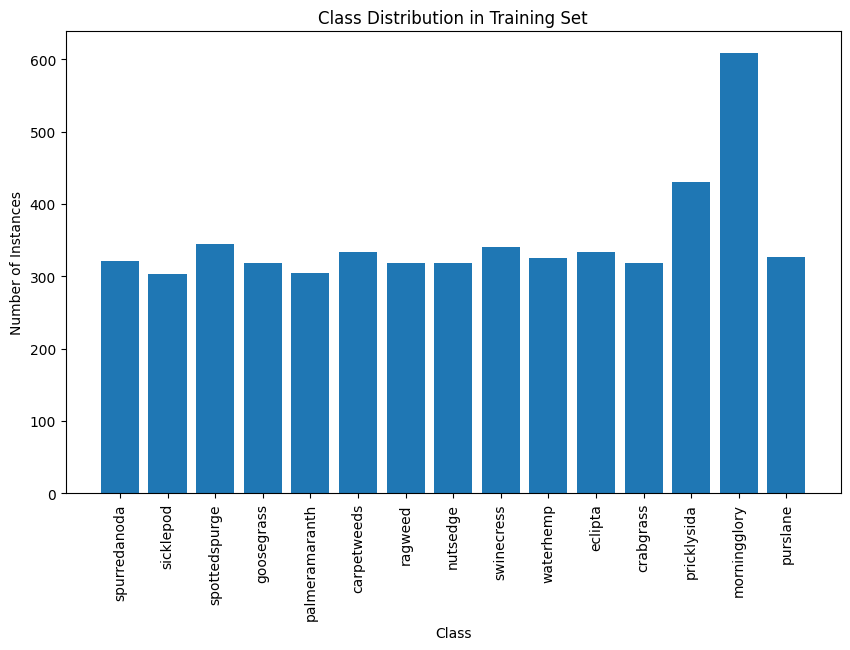

In [ ]:
# Parse class labels from YOLO label files
label_files = glob(os.path.join(train_path.replace('images', 'labels'), '*.txt'))

def parse_labels(label_file):
    with open(label_file, 'r') as f:
        labels = [line.split()[0] for line in f.readlines()]  # Extract class IDs
    return labels

# Count occurrences of each class
class_counts = Counter()
for label_file in label_files:
    class_counts.update(parse_labels(label_file))

# Map class indices to class names
class_distribution = {class_names[int(cls)]: count for cls, count in class_counts.items()}

# Plot the class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Instances")
plt.xlabel("Class")
plt.show()


**Analyse Image Sizes**

Analyzse and display statistics about image sizes in the training set to the summary table of image size statistics (min, max, mean, etc.).


In [ ]:
# Analyze image sizes in the training set
image_files = glob(os.path.join(train_path, '*.jpg'))

image_shapes = []
for image_file in image_files:
    img = cv2.imread(image_file)  # Read the image
    if img is not None:  # Ensure the image is loaded successfully
        image_shapes.append(img.shape[:2])  # Store height and width of the image

# Convert to DataFrame and analyze
image_shapes_df = pd.DataFrame(image_shapes, columns=['Height', 'Width'])

# Display statistics of image sizes in a tabular format
print("Image Size Summary:")
print(image_shapes_df.describe().to_string())


Image Size Summary:
       Height   Width
count  4716.0  4716.0
mean    256.0   256.0
std       0.0     0.0
min     256.0   256.0
25%     256.0   256.0
50%     256.0   256.0
75%     256.0   256.0
max     256.0   256.0


**Visualize Sample Images**

Displays a 4x4 grid of 16 sample images from the training set.

In [ ]:
# Function to wrap long file names
def wrap_text(text, length=15):
    return '\n'.join([text[i:i+length] for i in range(0, len(text), length)])

# Function to visualize sample images in a 3x4 grid (16 images total)
def visualize_sample_images(image_path, sample_size=16, cols=4):
    sample_images = glob(os.path.join(image_path, '*.jpg'))[:sample_size]

    # Create a grid for images
    rows = sample_size // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 13))  # Create grid of subplots
    axes = axes.ravel()  # Flatten the 2D array of axes into a 1D array

    for i, img_file in enumerate(sample_images):
        img = cv2.imread(img_file)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)

        # Wrap long image names and set as title
        image_name = os.path.basename(img_file)
        wrapped_name = wrap_text(image_name, length=25)  # Wrap after 15 characters
        axes[i].set_title(wrapped_name, fontsize=14)  # Set the title with smaller font size

        axes[i].axis('off')  # Turn off axis for cleaner display

    plt.tight_layout(pad=2.0)  # Adjust spacing
    plt.show()

# Visualize 16 sample images from the training set in a 3x4 grid
visualize_sample_images(train_path, sample_size=16, cols=4)


Output hidden; open in https://colab.research.google.com to view.

# **4. Model Training**
**Train YOLOv8 Model**

Run the YOLOv8 training process for 100 epochs with specified parameters, train the model and save.

In [ ]:
!yolo train model=yolov8n.pt data=/content/weed_detection-1/data.yaml epochs=100 imgsz=640

100% 6.25M/6.25M [00:00<00:00, 222MB/s]
Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/weed_detection-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_

# **5. Results Analysis**
**Installing Pillow and Importing Libraries**

Install Pillow and import required necessary libraries for results analysis.


In [ ]:
!pip install pillow

import os
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
from ultralytics import YOLO
from PIL import Image

**Analyse Training Results**

Reads and display the training results from the CSV file in a table of training metrics and losses over epochs.

In [ ]:
# Check if the CSV file exists
csv_file_path = 'runs/detect/train/results.csv'
if os.path.exists(csv_file_path):
    # Load the CSV file and strip leading/trailing spaces from column names
    results = pd.read_csv(csv_file_path)
    results.columns = results.columns.str.strip()  # Remove leading/trailing spaces

    # Check the available columns in the CSV
    print("Columns in the CSV:", results.columns)

    # Tabulate the results
    columns_to_display = [
        'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
        'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
    ]

    table_data = results[columns_to_display].round(4)  # Round to 4 decimal places
    print("\nTabulated Results:")
    print(tabulate(table_data, headers='keys', tablefmt='pretty', showindex=False))

else:
    print(f"File {csv_file_path} does not exist.")

Columns in the CSV: Index(['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

Tabulated Results:
+-------+----------------+----------------+----------------+----------------------+-------------------+------------------+---------------------+
| epoch | train/box_loss | train/cls_loss | train/dfl_loss | metrics/precision(B) | metrics/recall(B) | metrics/mAP50(B) | metrics/mAP50-95(B) |
+-------+----------------+----------------+----------------+----------------------+-------------------+------------------+---------------------+
|  1.0  |     0.7425     |     3.0638     |     1.3817     |        0.4147        |       0.616       |      0.449       |       0.3472        |
|  2.0  |     0.6801     |     2.0736     |     1.3272     |        0.5191        |      0.6166     

**Plot Training Losses**

Create a plot of different loss components over training epochs to show the progression of box loss, classification loss, and DFL loss.

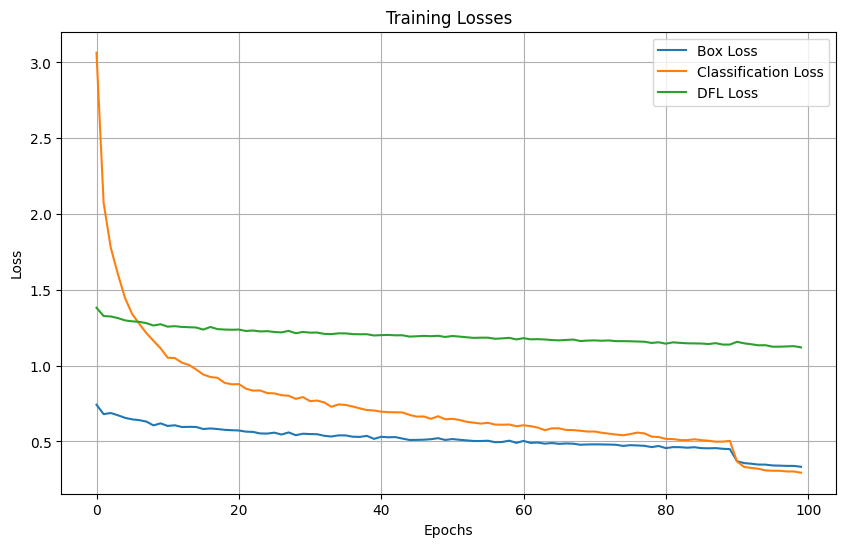

In [ ]:
    # Plot the losses
    if 'train/box_loss' in results.columns and 'train/cls_loss' in results.columns and 'train/dfl_loss' in results.columns:
        plt.figure(figsize=(10, 6))
        plt.plot(results['train/box_loss'], label='Box Loss')
        plt.plot(results['train/cls_loss'], label='Classification Loss')
        plt.plot(results['train/dfl_loss'], label='DFL Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training Losses')
        plt.legend()
        plt.grid(True)
        plt.show()

**Plot Precision, Recall, and mAP**

Plot precision, recall, mAP50, and mAP50-95 metrics over epochs to show the progression of these metrics during training.


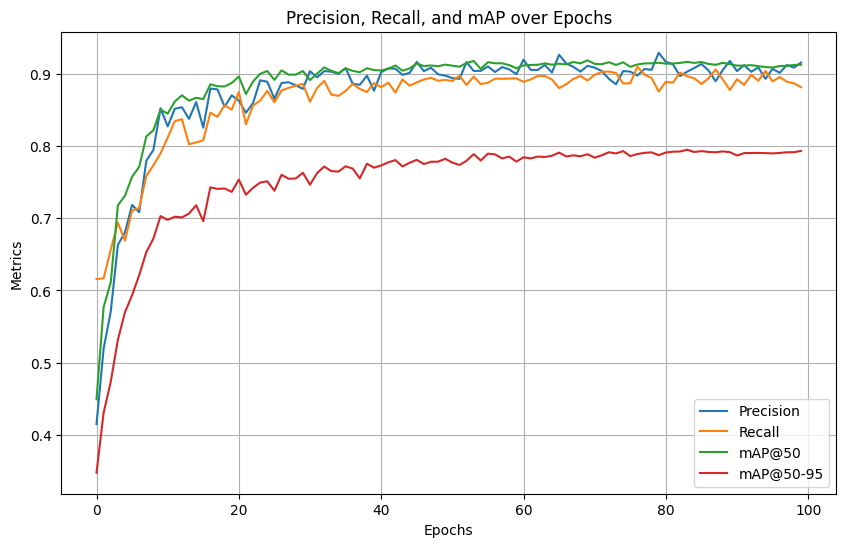

In [ ]:
    # Plot Precision, Recall, mAP50, and mAP50-95
    plt.figure(figsize=(10, 6))
    plt.plot(results['metrics/precision(B)'], label='Precision')
    plt.plot(results['metrics/recall(B)'], label='Recall')
    plt.plot(results['metrics/mAP50(B)'], label='mAP@50')
    plt.plot(results['metrics/mAP50-95(B)'], label='mAP@50-95')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.title('Precision, Recall, and mAP over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

**Generate and Display Confusion Matrix**

Generate a confusion matrix from the validation results and displays it to show the summary of validation metrics.

Columns in the CSV: Index(['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

Generating and Displaying Confusion Matrix...
Ultralytics YOLOv8.2.101 🚀 Python-3.10.12 torch-2.4.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/weed_detection-1/valid/labels.cache... 1347 images, 6 backgrounds, 0 corrupt: 100%|██████████| 1347/1347 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1271, len(boxes) = 1484. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 85/85 [07:32<00:00,  5.32s/it]


                   all       1347       1484      0.903      0.898      0.917      0.795
           carpetweeds         86         94      0.879       0.83      0.894      0.739
             crabgrass         92         93      0.968      0.968      0.953      0.875
               eclipta         90         93      0.924      0.903      0.923      0.772
            goosegrass         83         84          1      0.935      0.977      0.894
          morningglory         88        169      0.741      0.627      0.672      0.452
              nutsedge         86         86      0.869      0.837      0.891      0.724
        palmeramaranth         94         96      0.819      0.875      0.826      0.676
           pricklysida         88        113      0.766      0.894      0.924      0.774
              purslane         93         98      0.917      0.905      0.939      0.792
               ragweed         93         94      0.989      0.987      0.989      0.973
             sicklepo

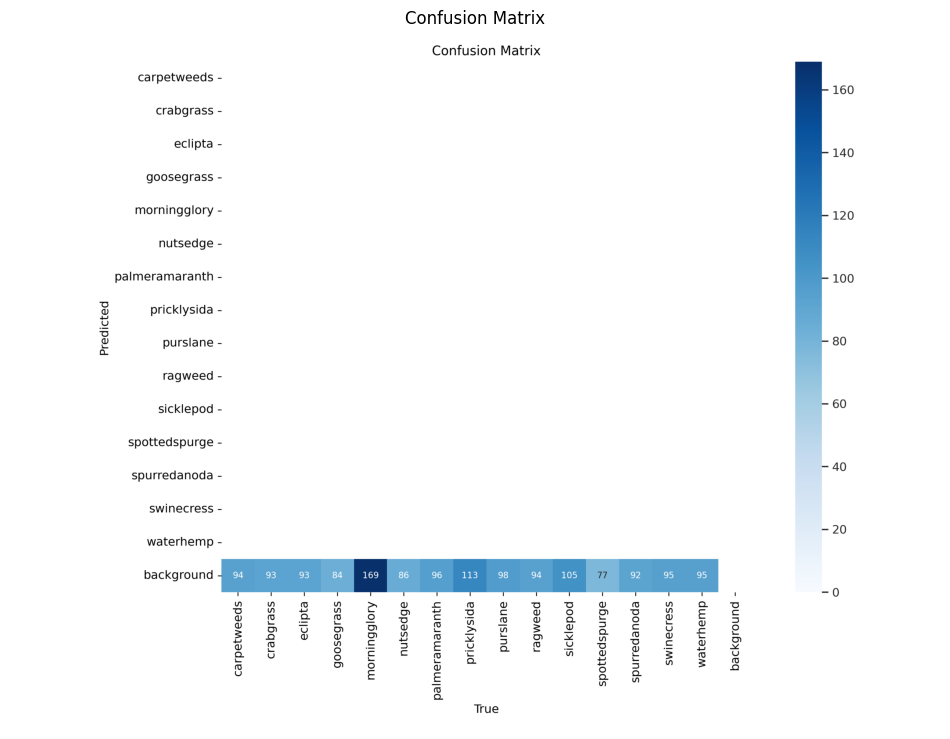

Confusion Matrix displayed.

Validation Metrics:
metrics/precision(B): 0.9034
metrics/recall(B): 0.8975
metrics/mAP50(B): 0.9167
metrics/mAP50-95(B): 0.7951
fitness: 0.8073


In [ ]:
# Check if the CSV file exists
csv_file_path = 'runs/detect/train/results.csv'
if os.path.exists(csv_file_path):
    # Load the CSV file and strip leading/trailing spaces from column names
    results = pd.read_csv(csv_file_path)
    results.columns = results.columns.str.strip()  # Remove leading/trailing spaces

    # Check the available columns in the CSV
    print("Columns in the CSV:", results.columns)

    # Generate and Display Confusion Matrix
    print("\nGenerating and Displaying Confusion Matrix...")
    model = YOLO('runs/detect/train/weights/best.pt')
    results = model.val(save_conf=False, plots=True, save_json=False, task='detect')

    # Path to the confusion matrix image
    confusion_matrix_path = 'runs/detect/val/confusion_matrix.png'

    if os.path.exists(confusion_matrix_path):
        # Load and display the confusion matrix
        confusion_matrix = Image.open(confusion_matrix_path)
        plt.figure(figsize=(12, 10))
        plt.imshow(confusion_matrix)
        plt.axis('off')
        plt.title('Confusion Matrix')
        plt.show()
        print("Confusion Matrix displayed.")
    else:
        print(f"Confusion matrix not found at {confusion_matrix_path}")

    # Display metrics from validation results
    print("\nValidation Metrics:")
    metrics = results.results_dict
    for key, value in metrics.items():
        if isinstance(value, (int, float)):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")


else:
    print(f"File {csv_file_path} does not exist.")

# **6. Improve Model**
**Retrain the Model**

Retrain the model using the best weights from the previous training session so as to improve the performance of the model.

In [ ]:
# Retrain the Model
!yolo train model=/content/runs/detect/train/weights/best.pt data=/content/weed_detection-1/data.yaml epochs=100 imgsz=640

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=/content/runs/detect/train/weights/best.pt, data=/content/weed_detection-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, sh

# **7. Test Model and Visualize Result**
**Test Model and Visualize Result**

Uses the trained model to make predictions on the test dataset and visualizes the results in *a* 4x4 grid of images showing the model's predictions on test data.

In [ ]:
# Load the trained model
model = YOLO('runs/detect/train/weights/best.pt')  # Path to the best model

# Suppress print output during predictions
import contextlib
with contextlib.redirect_stdout(None):
    # Test the model on the test dataset and suppress output
    results = model.predict(source='/content/weed_detection-1/test/images', save=True, show=False)

# Path where the prediction results are saved
predicted_images_path = '/content/runs/detect/predict/'

# Function to wrap long file names
def wrap_text(text, length=15):
    return '\n'.join([text[i:i+length] for i in range(0, len(text), length)])

# Function to visualize sample images in a 4x4 grid (16 images total)
def visualize_sample_images(image_path, sample_size=16, cols=4):
    # Get paths of predicted images
    sample_images = glob(os.path.join(image_path, '*.jpg'))[:sample_size]

    # Create a grid for images
    rows = sample_size // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 13))  # Create grid of subplots
    axes = axes.ravel()  # Flatten the 2D array of axes into a 1D array

    for i, img_file in enumerate(sample_images):
        img = cv2.imread(img_file)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)

        # Wrap long image names and set as title
        image_name = os.path.basename(img_file)
        wrapped_name = wrap_text(image_name, length=25)  # Wrap after 25 characters
        axes[i].set_title(wrapped_name, fontsize=10)  # Set the title with a smaller font size

        axes[i].axis('off')  # Turn off axis for cleaner display

    plt.tight_layout(pad=2.0)  # Adjust spacing
    plt.show()

# Visualize 16 sample images from the predicted results in a 4x4 grid
visualize_sample_images(predicted_images_path, sample_size=16, cols=4)


Output hidden; open in https://colab.research.google.com to view.

# **8. Save and Load Project Files from Drive**
**Mount Google Drive**

Mounts Google Drive to allow accessible and file transfer between Colab and Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Copy Files to Google Drive**

Copy the project files and trained model to Google Drive and saved to this Drive location.

"/content/drive/My Drive/Colab Notebooks/Weed detectio"


In [ ]:
import shutil
import os

# Define the source paths
weed_detection_folder = '/content/weed_detection-1'
runs_folder = '/content/runs'
yolov8n_pt_file = '/content/yolov8n.pt'

# Define the destination paths in your Google Drive
drive_path = '/content/drive/My Drive/Colab Notebooks/Weed detection'

# Copy the folders and file
shutil.copytree(weed_detection_folder, os.path.join(drive_path, 'weed_detection-1'))
shutil.copytree(runs_folder, os.path.join(drive_path, 'runs'))
shutil.copy(yolov8n_pt_file, os.path.join(drive_path, 'yolov8n.pt'))

**Copy Files from Google Drive to Colab**

Copy the project files and model from Drive back into the Colab environment.

In [3]:
import shutil
import os

# Define the source paths in your Google Drive
drive_path = '/content/drive/My Drive/Colab Notebooks/Weed detection'
weed_detection_folder = os.path.join(drive_path, 'weed_detection-1')
runs_folder = os.path.join(drive_path, 'runs')
yolov8n_pt_file = os.path.join(drive_path, 'yolov8n.pt')

# Define the destination paths in your Colab folder
colab_path = '/content'
colab_weed_detection_folder = os.path.join(colab_path, 'weed_detection-1')
colab_runs_folder = os.path.join(colab_path, 'runs')
colab_yolov8n_pt_file = os.path.join(colab_path, 'yolov8n.pt')

# Copy the folders and file back to Colab
shutil.copytree(weed_detection_folder, colab_weed_detection_folder)
shutil.copytree(runs_folder, colab_runs_folder)
shutil.copy(yolov8n_pt_file, colab_yolov8n_pt_file)

'/content/yolov8n.pt'

# **9. Export the trained YOLOv8 model**
**Export Model**

Export the trained YOLOv8 model to a format suitable for mobile deployment. TensorFlow Lite (TFLite) is a good choice which will create a file named best_int8.tflite in the same directory as your model..

In [10]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Export the model to TFLite format
model.export(format='tflite', int8=True)

Ultralytics 8.3.6 🚀 Python-3.10.12 torch-2.4.1+cu121 CPU (Intel Xeon 2.20GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
Model summary (fused): 168 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (6.0 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'onnx>=1.12.0', 'onnx2tf>1.17.5,<=1.22.3', 'onnxslim>=0.1.31', 'tflite_support', 'onnxruntime'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.6/136.6 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 178.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.0/43

100%|██████████| 1.11M/1.11M [00:00<00:00, 111MB/s]
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100%|██████████| 1/1 [00:00<00:00, 46.80file/s]

requirements: Ultralytics requirement ['onnxslim==0.1.34'] not found, attempting AutoUpdate...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.3/140.3 kB 29.1 MB/s eta 0:00:00
  Attempting uninstall: onnxslim
    Found existing installation: onnxslim 0.1.35
    Uninstalling onnxslim-0.1.35:
      Successfully uninstalled onnxslim-0.1.35

requirements: AutoUpdate success ✅ 2.9s, installed 1 package: ['onnxslim==0.1.34']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.34...
ONNX: export success ✅ 5.0s, saved as '/content/runs/detect/train/weights/best.onnx' (11.8 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8.yaml'

Dataset 'coco8.yaml' images not found ⚠️, missing path '/content/datasets/coco8/images/val'


100%|██████████| 433k/433k [00:00<00:00, 6.25MB/s]
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100%|██████████| 25/25 [00:00<00:00, 4135.42file/s]

Dataset download success ✅ (1.6s), saved to /content/datasets



100%|██████████| 755k/755k [00:00<00:00, 77.3MB/s]
Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<00:00, 462.91it/s]

New cache created: /content/datasets/coco8/labels/val.cache
TensorFlow SavedModel: WARNING ⚠️ >300 images recommended for INT8 calibration, found 4 images.
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.22.3...



Automatic generation of each OP name started ========================================
Automatic generation of each OP name complete!

Model loaded ========================================================================

Model conversion started ============================================================
saved_model output started ==========================================================
saved_model output complete!
Float32 tflite output complete!
Float16 tflite output complete!
Dynamic Range Quantization tflite output complete!
Input signature information for quantization
signature_name: serving_default
input_name.0: images shape: (1, 640, 640, 3) dtype: <dtype: 'float32'>
INT8 Quantization tflite output complete!
Full INT8 Quantization tflite output complete!
INT8 Quantization with int16 activations tflite output complete!
Full INT8 Quantization with int16 activations tflite output complete!
TensorFlow SavedModel: export success ✅ 97.8s, saved as '/content/runs/detect/train/weight

'/content/runs/detect/train/weights/best_saved_model/best_int8.tflite'